USING LOG

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('england_master.csv')
df.rename(columns={'Unnamed: 0': 'Quarter'}, inplace=True)
df['Quarter'] = pd.PeriodIndex(df['Quarter'], freq='Q')
df.set_index('Quarter', inplace=True)

In [3]:
df['log_starts'] = np.log(df['starts'])
df['log_hprice'] = np.log(df['hprice'])
df['log_cc'] = np.log(df['cc'])
df['log_vol'] = np.log(df['vol'])
df['rate'] = df['rate']

In [4]:
df['log_starts_lag1'] = df['log_starts'].shift(1)
df['log_starts_lag4'] = df['log_starts'].shift(4)
df['log_hprice_lag1'] = df['log_hprice'].shift(1)
df['log_cc_lag1'] = df['log_cc'].shift(1)
df['log_vol_lag1'] = df['log_vol'].shift(1)
df['rate_lag1'] = df['rate'].shift(1)
df['rate_lag4'] = df['rate'].shift(4)

In [5]:
df_clean = df.dropna()

In [6]:
target = 'log_starts'
features = [
    'log_starts_lag1', 'log_starts_lag4',
    'log_hprice_lag1', 'log_cc_lag1',
    'rate_lag1', 'rate_lag4', 'log_vol_lag1'
]

X = df_clean[features]
y = df_clean[target]

In [7]:
train = df_clean.index < pd.Period('2020Q1', freq='Q')
test = df_clean.index >= pd.Period('2020Q1', freq='Q')

X_train, y_train = X[train], y[train]
X_test, y_test = X[test], y[test]

In [8]:
#TIMESERIESCV

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [2, 5]
}

In [9]:
rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [10]:
#Fitting training data

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

In [11]:
#OUT OF SAMPLE

preds_log = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds_log))
mae = mean_absolute_error(y_test, preds_log)

y_test_array = y_test.values

r2 = r2_score(y_test, preds_log)


mape = np.mean(np.abs((y_test_array - preds_log/ y_test_array)))
mape_percentage= mape*100

print(f"\nOut-of-Sample Performance (2020-2026):")
print(f"MAE: {mae:.2f} units")
print(f"Log-Scale RMSE: {rmse:.2f} units")
print(f"Log-Scale MAPE: {mape:.2f}%")
print(f"Pseudo R2: {r2:.4f}")


Out-of-Sample Performance (2020-2026):
MAE: 0.24 units
Log-Scale RMSE: 0.32 units
Log-Scale MAPE: 9.17%
Pseudo R2: 0.1916


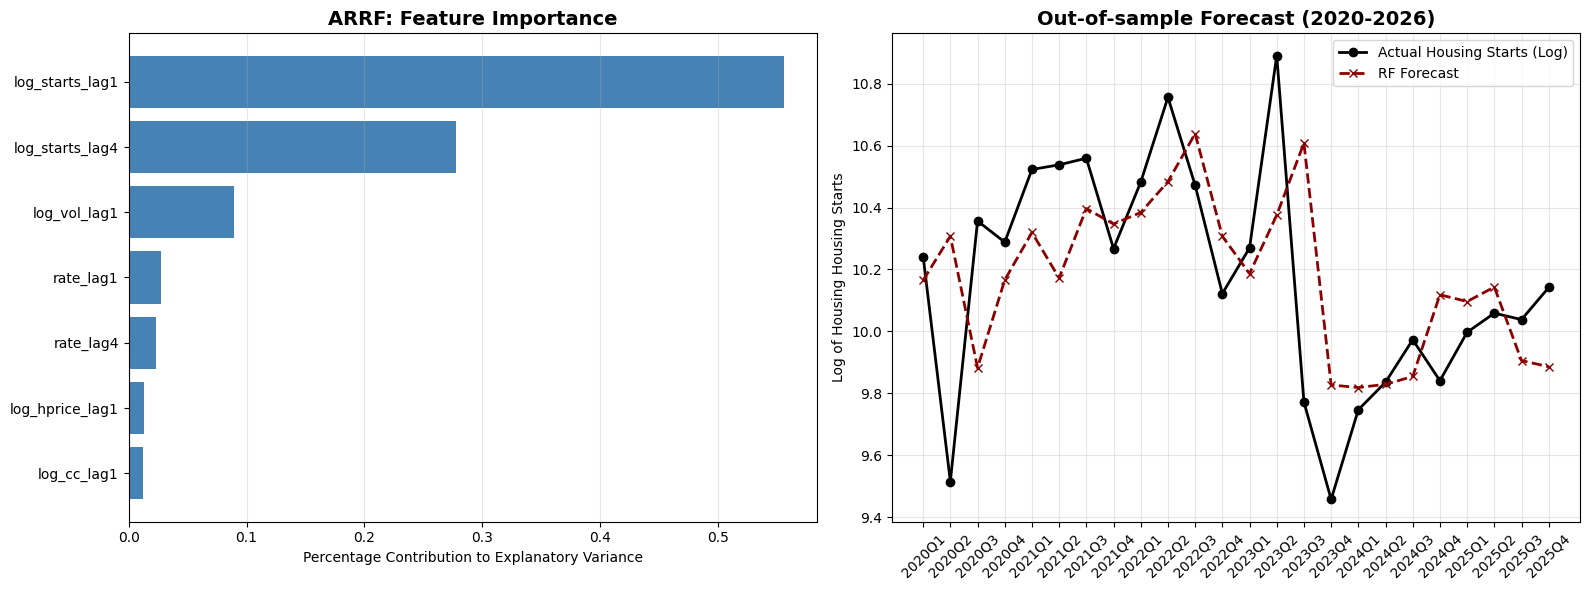

In [12]:
#plot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Feature Importance
importances = best_rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances}). sort_values(by='Importance', ascending=True)

axes[0].barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
axes[0].set_title('ARRF: Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Percentage Contribution to Explanatory Variance')
axes[0].grid(axis='x', alpha=0.3)

#plot2 out of sample forecast
test_dates = y_test.index.astype(str)
axes[1].plot(test_dates, y_test.values, label='Actual Housing Starts (Log)', color='black', marker='o', linewidth=2)
axes[1].plot(test_dates, preds_log, label='RF Forecast', color='darkred', linestyle='--', marker='x', linewidth=2)

axes[1].set_title('Out-of-sample Forecast (2020-2026)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log of Housing Housing Starts')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arrf_results.png')
plt.show()

In [16]:
#to view the forecasted values IN LOG
forecast_df = pd.DataFrame({
    'Quarter': X_test.index,
    'Forecasted_Smoothed_Starts': preds_log
})

# Display the table
print("\n--- FORECASTED HOUSING STARTS (2020-2026) ---")
print(forecast_df.to_string(index=False))


--- FORECASTED HOUSING STARTS (2020-2026) ---
Quarter  Forecasted_Smoothed_Starts
 2020Q1                   10.164924
 2020Q2                   10.307273
 2020Q3                    9.882194
 2020Q4                   10.165869
 2021Q1                   10.319515
 2021Q2                   10.172151
 2021Q3                   10.396715
 2021Q4                   10.346791
 2022Q1                   10.383878
 2022Q2                   10.483561
 2022Q3                   10.638756
 2022Q4                   10.307207
 2023Q1                   10.186331
 2023Q2                   10.375528
 2023Q3                   10.608128
 2023Q4                    9.826631
 2024Q1                    9.818522
 2024Q2                    9.828848
 2024Q3                    9.854279
 2024Q4                   10.118252
 2025Q1                   10.096335
 2025Q2                   10.143213
 2025Q3                    9.905522
 2025Q4                    9.885654


In [18]:
physical_preds = np.exp(preds_log)

results_table = pd.DataFrame({
    'Quarter': X_test.index,
    'Forecasted_Houses': np.round(physical_preds, 0)
})

print("\n--- FORECASTED HOUSING STARTS (PHYSICAL UNITS) ---")
print(results_table.to_string(index=False))

print("\nForecast for 2025Q4:")
val_2025q4 = results_table[results_table['Quarter'] == '2025Q4']['Forecasted_Houses'].values[0]
print(f"Number of houses: {val_2025q4:,.0f}")


--- FORECASTED HOUSING STARTS (PHYSICAL UNITS) ---
Quarter  Forecasted_Houses
 2020Q1            25976.0
 2020Q2            29950.0
 2020Q3            19579.0
 2020Q4            26000.0
 2021Q1            30319.0
 2021Q2            26164.0
 2021Q3            32752.0
 2021Q4            31157.0
 2022Q1            32334.0
 2022Q2            35723.0
 2022Q3            41721.0
 2022Q4            29948.0
 2023Q1            26538.0
 2023Q2            32065.0
 2023Q3            40462.0
 2023Q4            18520.0
 2024Q1            18371.0
 2024Q2            18562.0
 2024Q3            19040.0
 2024Q4            24791.0
 2025Q1            24254.0
 2025Q2            25418.0
 2025Q3            20041.0
 2025Q4            19646.0

Forecast for 2025Q4:
Number of houses: 19,646
